[![Chat-GPT-Image-Aug-25-2026-06-59-16-PM.png](https://i.postimg.cc/Wp9fqDP5/Chat-GPT-Image-Aug-25-2026-06-59-16-PM.png)](https://postimg.cc/6TvhDpqZ)

[![Chat-GPT-Image-Aug-25-2026-07-00-25-PM.png](https://i.postimg.cc/9XxNw4jn/Chat-GPT-Image-Aug-25-2026-07-00-25-PM.png)](https://postimg.cc/grZKf2jV)

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    # 1. Normal / Gaussian
    "normal": np.random.normal(loc=50, scale=10, size=n),

    # 2. Right-skewed
    "right_skewed": np.random.exponential(scale=20, size=n),

    # 3. Left-skewed
    "left_skewed": 100 - np.random.exponential(scale=20, size=n),

    # 4. Uniform
    "uniform": np.random.uniform(low=0, high=100, size=n),

    # 5. Log-normal (strong right skew)
    "log_normal": np.random.lognormal(mean=2, sigma=0.8, size=n),

    # 6. Bimodal
    "bimodal": np.concatenate([
        np.random.normal(30, 5, n // 2),
        np.random.normal(70, 5, n // 2)
    ]),

    # 7. Poisson / count data
    "poisson": np.random.poisson(lam=5, size=n),

    # 8. Chi-square (right skewed)
    "chi_square": np.random.chisquare(df=3, size=n)
})

df.head()

,normal,right_skewed,left_skewed,uniform,log_normal,bimodal,poisson,chi_square
0,54.967142,3.666023,95.054635,64.831801,6.964471,31.621701,4,2.118754
1,48.617357,2.208976,99.251749,7.410542,6.955047,27.336373,5,3.707352
2,56.476885,20.235682,97.713640,37.546893,35.803073,34.198319,5,10.078920
3,65.230299,24.515899,91.724187,80.381455,2.438077,23.212412,4,1.886267
4,47.658466,0.641915,67.550988,43.347223,11.072576,25.496643,5,2.668732


In [2]:
from sklearn.preprocessing import PowerTransformer

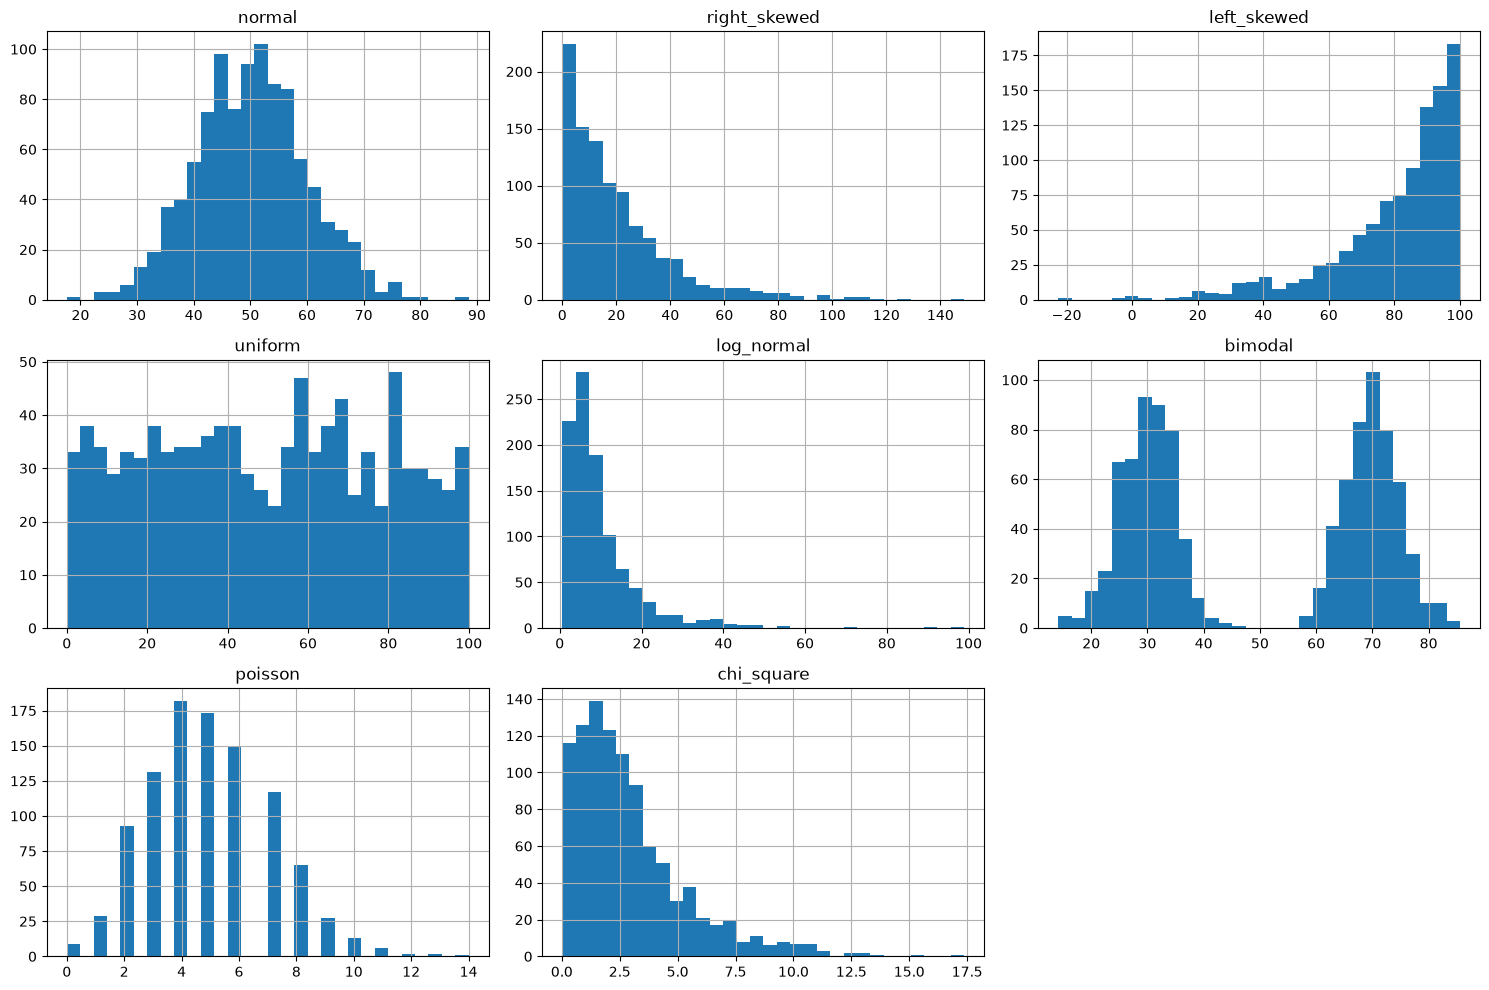

In [3]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
pt = PowerTransformer(method = 'yeo-johnson') # Box-Cox
df_transformed = pt.fit_transform(df + 0.00001)

df_transformed = pd.DataFrame(
    df_transformed,
    columns= df.columns
)

# Standardises data by default


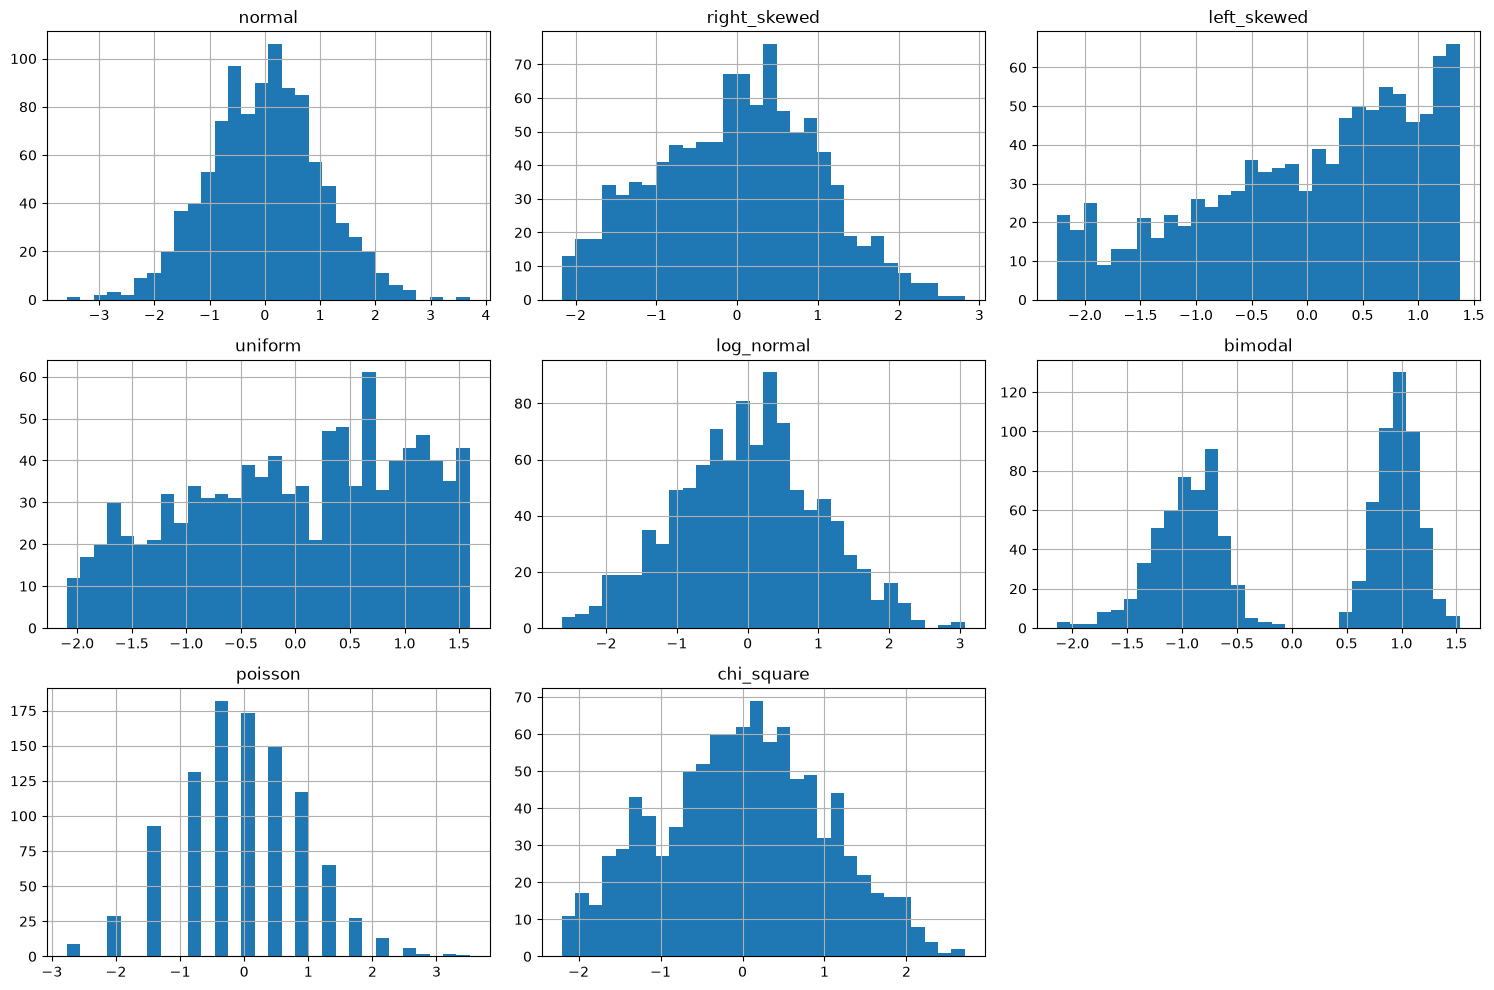

In [5]:
df_transformed.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

In [6]:
from scipy.stats import skew
print(skew(df))

[ 1.16800831e-01  1.98081195e+00 -1.63537773e+00  1.42634209e-02
  3.24353889e+00  5.39192979e-04  3.92359577e-01  1.66063548e+00]


In [10]:
# Obtain Lambdas

print(pt.lambdas_)

[ 0.81303221  0.15531048  2.73358423  0.71520669 -0.14950092  0.41311865
  0.66238064 -0.13563459]
